# Week 3: Nemotron Nano 4B Experiments
**Depends on:** `week1_baselines.ipynb` must be run first to generate shared splits.

**This notebook:**
1. Loads train/test splits from Week 1
2. Audits surviving occupations as yes/no/maybe
3. Checks yes/no/maybe balance
4. Shows timing estimate before running experiments
5. Runs zero-shot and few-shot experiments on the 20% test set
6. Analyzes accuracy by occupation difficulty and K-Means clusters

**Baselines (Week 1 - shared splits):**
- Random Forest: 64.42% accuracy, Macro F1 0.6400
- XGBoost: 68.82% accuracy, Macro F1 0.6839

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import re
import os

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("Imports OK")

Imports OK


## 2. Load Shared Splits from Week 1

Loads the train/test splits generated by `week1_baselines.ipynb`.
The splits already have the 10-row occupation cutoff and 80/20 split applied.

> Run `week1_baselines.ipynb` first if the files do not exist yet.

In [2]:
import os

TRAIN_PATH  = "../data/week3_train_5000.csv"
TEST_PATH   = "../data/week3_test_5000.csv"
RESULTS_DIR = "../results"
DATA_DIR    = "../data"
os.makedirs(RESULTS_DIR, exist_ok=True)

if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    print("Split files not found.")
    print("Run week1_baselines.ipynb first to generate the shared splits.")
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)

    print(f"Train: {len(df_train):,} rows")
    print(f"Test:  {len(df_test):,} rows")
    print(f"Surviving occupations in test: {df_test['occupation'].nunique()}")
    print(f"\nTest label balance:")
    print(df_test['label_name'].value_counts())
    print()
    df_test.head(3)


Train: 2,460 rows
Test:  615 rows
Surviving occupations in test: 75

Test label balance:
label_name
not_college    336
college        279
Name: count, dtype: int64



## 3. Manual Audit - All Surviving Occupations

Look at the unique occupations in the test set and categorize each one.

**Categories:**
- `"yes"`: clearly requires a college degree
- `"no"`: clearly does not require a college degree
- `"maybe"`: ambiguous, could go either way

**Numeric encoding:** no=0, yes=1, maybe=2

In [3]:
# Show all unique occupations in the test set
surviving_occs = sorted(df_test["occupation"].str.replace("_", " ").str.strip().str.lower().unique())
print(f"Occupations in test set: {len(surviving_occs)}")
for i, occ in enumerate(surviving_occs, 1):
    print(f"  {i:2d}. {occ}")
print()
print("Fill in occupation_audit below with yes/no/maybe for each one.")


Occupations in test set: 75
   1. accountant or auditor
   2. assembler or fabricator
   3. automotive service technician or mechanic
   4. bookkeeping accounting or auditing clerk
   5. bus driver school
   6. business operations specialist
   7. carpenter
   8. cashier
   9. chief executive
  10. childcare worker
  11. civil engineer
  12. clergy
  13. computer occupation
  14. computer support specialist
  15. computer systems analyst
  16. construction laborer
  17. construction manager
  18. cook
  19. courier or messenger
  20. customer service representative
  21. driver sales worker or truck driver
  22. education or childcare administrator
  23. electrician
  24. elementary or middle school teacher
  25. engineer
  26. engineering technologist or technician
  27. financial manager
  28. first line supervisor of non retail sales worker
  29. first line supervisor of office or administrative support worker
  30. first line supervisor of production or operating worker
  31. first

In [4]:
# ── FILL THIS IN AFTER RUNNING CELL 3 ────────────────────────────────

occupation_audit = {
    # Paste your surviving occupations here, one per line:
    # "occupation name": "yes/no/maybe",

    # Pre-filled from previous audit (update if occupation appears again):
    "advertising or promotions manager":                                          "yes",
    "animal trainer":                                                             "no",
    "barber":                                                                     "no",
    "budget analyst":                                                             "yes",
    "chief executive":                                                            "yes",
    "chiropractor":                                                               "yes",
    "compliance officer":                                                         "maybe",
    "construction equipment operator":                                            "no",
    "credit counselor or loan officer":                                           "maybe",
    "customer service representative":                                            "no",
    "dental or ophthalmic laboratory technician or medical appliance technician": "maybe",
    "designer":                                                                   "maybe",
    "fast food or counter worker":                                                "no",
    "first line supervisor of housekeeping or janitorial worker":                 "no",
    "industrial truck or tractor operator":                                       "no",
    "information security analyst":                                               "yes",
    "inspector tester sorter sampler or weigher":                                 "no",
    "laundry or dry cleaning worker":                                             "no",
    "mechanical engineer":                                                        "yes",
    "office clerk general":                                                       "no",
    "pharmacist":                                                                 "yes",
    "physical therapist":                                                         "yes",
    "preschool or kindergarten teacher":                                          "yes",
    "reservation or transportation ticket agent or travel clerk":                 "no",
    "social or human service assistant":                                          "maybe",
    "surgical technologist":                                                      "yes",
    "teacher or instructor":                                                      "yes",
    "training or development specialist":                                         "maybe",
    "weigher measurer checker or sampler recordkeeping":                          "no",
    "wholesale or retail buyer":                                                  "maybe",
    "shipping receiving or inventory clerk":                      "no",
    "driver sales worker or truck driver":                        "no",
    "computer support specialist":                                "maybe", # Frequently Associate's or cert-driven
    "cashier":                                                    "no",
    "software developer":                                         "yes",
    "police officer":                                             "maybe", # Highly variable requirements by state/precinct
    "janitor or building cleaner":                                "no",
    "registered nurse":                                           "yes",   # ADN (Associate Degree) is the baseline entry
    "miscellaneous agricultural worker":                          "no",
    "retail salesperson":                                         "no",
    "secondary school teacher":                                   "yes",
    "customer service representative":                            "no",
    "general or operations manager":                              "maybe", # Mix of experience-led and business degrees
    "landscaping or groundskeeping worker":                        "no",
    "sales representative wholesale or manufacturing":            "maybe",
    "manager":                                                    "maybe",
    "personal care aide":                                         "no",
    "receptionist or information clerk":                          "no",
    "computer systems analyst":                                   "yes",
    "project management specialist":                              "yes",
    "postsecondary teacher":                                      "yes",
    "elementary or middle school teacher":                        "yes",
    "automotive service technician or mechanic":                  "no",
    "industrial truck or tractor operator":                       "no",
    "first line supervisor of retail sales worker":               "no",    # Usually promoted via retail experience
    "office clerk general":                                       "no",
    "carpenter":                                                  "no",
    "sales representative of services":                           "maybe",
    "stocker or order filler":                                    "no",
    "waiter or waitress":                                         "no",
    "courier or messenger":                                       "no",
    "real estate broker or sales agent":                          "no",    # Handled via high school + real estate license course
    "first line supervisor of production or operating worker":    "no",
    "management analyst":                                         "yes",
    "personal financial advisor":                                 "yes",
    "inspector tester sorter sampler or weigher":                 "no",
    "accountant or auditor":                                      "yes",
    "civil engineer":                                             "yes",
    "bus driver school":                                          "no",
    "licensed practical or licensed vocational nurse":            "maybe", # Mix of vocational certificates and Associate's
    "maintenance or repair worker general":                        "no",
    "secretary or administrative assistant":                      "no",
    "construction laborer":                                       "no",
    "teaching assistant":                                         "maybe", # Many public districts mandate an Associate's
    "physician":                                                  "yes",
    "medical or health services manager":                         "yes",
    "bookkeeping accounting or auditing clerk":                   "maybe", # High concentration of Associate degrees
    "assembler or fabricator":                                    "no",
    "first line supervisor of non retail sales worker":           "maybe",
    "production worker":                                          "no",
    "clergy":                                                     "yes",   # Typically requires seminary/Master of Divinity
    "chief executive":                                            "yes",
    "laborer or freight stock or material mover":                 "no",
    "electrician":                                                "no",
    "maid or housekeeping cleaner":                               "no",
    "mathematical science occupation":                            "yes",
    "property real estate or community association manager":      "maybe",
    "financial manager":                                          "yes",
    "childcare worker":                                           "no",
    "engineer":                                                   "yes",
    "human resources worker":                                     "yes",
    "engineering technologist or technician":                     "maybe", # Classical Associate of Science engineering tier
    "cook":                                                       "no",
    "computer occupation":                                        "maybe",
    "insurance sales agent":                                      "no",
    "business operations specialist":                             "yes",
    "first line supervisor of office or administrative support worker": "no",
    "nursing assistant":                                          "no",    # CNA certifications are brief trade courses
    "teacher or instructor":                                      "yes",
    "market research analyst or marketing specialist":            "yes",
    "education or childcare administrator":                       "yes",
    "painter or paperhanger":                                     "no",
    "construction manager":                                       "maybe", # Heavily split between long field experience and BS degrees
    "security guard or gambling surveillance officer":            "no",
    "food service manager":                                       "maybe",
}

print(f"Audited: {len(occupation_audit)} occupations")

# Check how many surviving occupations still need to be audited
audit_normalized = {k.lower(): v for k, v in occupation_audit.items()}
surviving_clean = df_test["occupation"].str.replace("", " ").str.strip().str.lower().unique().tolist()
missing = [o for o in surviving_clean if o not in audit_normalized]

if missing:
    print(f"\n⚠ {len(missing)} surviving occupations NOT yet audited:")
    for m in missing:
        print(f"  - {m}")
    print("\nAdd these to occupation_audit above, then re-run this cell.")
else:
    print("✓ All surviving occupations are audited - run Cell 6.")

Audited: 99 occupations

⚠ 75 surviving occupations NOT yet audited:
  - s h i p p i n g _ r e c e i v i n g _ o r _ i n v e n t o r y _ c l e r k
  - d r i v e r _ s a l e s _ w o r k e r _ o r _ t r u c k _ d r i v e r
  - c o m p u t e r _ s u p p o r t _ s p e c i a l i s t
  - c a s h i e r
  - s o f t w a r e _ d e v e l o p e r
  - p o l i c e _ o f f i c e r
  - j a n i t o r _ o r _ b u i l d i n g _ c l e a n e r
  - r e g i s t e r e d _ n u r s e
  - m i s c e l l a n e o u s _ a g r i c u l t u r a l _ w o r k e r
  - r e t a i l _ s a l e s p e r s o n
  - s e c o n d a r y _ s c h o o l _ t e a c h e r
  - c u s t o m e r _ s e r v i c e _ r e p r e s e n t a t i v e
  - g e n e r a l _ o r _ o p e r a t i o n s _ m a n a g e r
  - l a n d s c a p i n g _ o r _ g r o u n d s k e e p i n g _ w o r k e r
  - s a l e s _ r e p r e s e n t a t i v e _ w h o l e s a l e _ o r _ m a n u f a c t u r i n g
  - m a n a g e r
  - p e r s o n a l _ c a r e _ a i d e
  - r e c e p t

In [5]:
# Map audit verdicts to train set as well
df_train["occ_clean"]      = df_train["occupation"].str.replace("_", " ").str.strip().str.lower()
df_train["audit_verdict"]  = df_train["occ_clean"].map(audit_normalized)
verdict_map = {"no": 0, "yes": 1, "maybe": 2}
df_train["verdict_num"]    = df_train["audit_verdict"].map(verdict_map)

print(f"Train rows with audit verdict: {df_train['audit_verdict'].notna().sum()}")
print(f"Train rows without verdict:    {df_train['audit_verdict'].isna().sum()}")

Train rows with audit verdict: 2460
Train rows without verdict:    0


## 4. Balance Check 

All rows have audit verdicts

Verdict distribution (rows):
audit_verdict
no       320
yes      183
maybe    112
Name: count, dtype: int64

Verdict distribution (%):
audit_verdict
no       52.0
yes      29.8
maybe    18.2
Name: proportion, dtype: float64


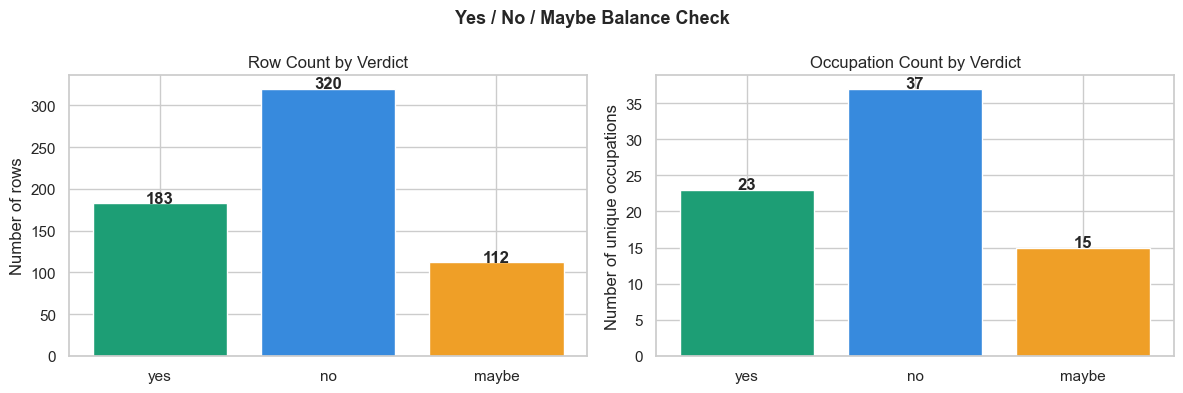

Saved: results/verdict_balance_check.png

Balance: Yes 30% / No 52% / Maybe 18%
Balanced - safe to proceed.


In [6]:
# Map verdicts to test set rows
df_test["occ_clean"]     = df_test["occupation"].str.replace("_", " ").str.strip().str.lower()
audit_normalized         = {k.lower(): v for k, v in occupation_audit.items()}
df_test["audit_verdict"] = df_test["occ_clean"].map(audit_normalized)

# Numeric encoding: no=0, yes=1, maybe=2
verdict_map = {"no": 0, "yes": 1, "maybe": 2}
df_test["verdict_num"] = df_test["audit_verdict"].map(verdict_map)

unaudited = df_test["audit_verdict"].isna().sum()
if unaudited > 0:
    print(f"Note: {unaudited} rows have unaudited occupations (verdict = NaN)")
else:
    print("All rows have audit verdicts")

print(f"\nVerdict distribution (rows):")
print(df_test["audit_verdict"].value_counts())
print(f"\nVerdict distribution (%):")
print((df_test["audit_verdict"].value_counts(normalize=True) * 100).round(1))

# Histogram
vc = df_test["audit_verdict"].value_counts().reindex(["yes", "no", "maybe"], fill_value=0)
colors = ["#1D9E75", "#378ADD", "#EF9F27"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_title("Row Count by Verdict")
axes[0].set_ylabel("Number of rows")
for i, val in enumerate(vc.values):
    axes[0].text(i, val + 0.5, str(val), ha="center", fontweight="bold")

occ_verdicts = df_test.drop_duplicates("occupation")["audit_verdict"].value_counts().reindex(
    ["yes", "no", "maybe"], fill_value=0
)
axes[1].bar(occ_verdicts.index, occ_verdicts.values, color=colors)
axes[1].set_title("Occupation Count by Verdict")
axes[1].set_ylabel("Number of unique occupations")
for i, val in enumerate(occ_verdicts.values):
    axes[1].text(i, val + 0.1, str(val), ha="center", fontweight="bold")

plt.suptitle("Yes / No / Maybe Balance Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/verdict_balance_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/verdict_balance_check.png")

yes_pct   = vc.get("yes",   0) / vc.sum() * 100
no_pct    = vc.get("no",    0) / vc.sum() * 100
maybe_pct = vc.get("maybe", 0) / vc.sum() * 100
print(f"\nBalance: Yes {yes_pct:.0f}% / No {no_pct:.0f}% / Maybe {maybe_pct:.0f}%")
if yes_pct >= 20 and no_pct >= 20 and maybe_pct >= 10:
    print("Balanced - safe to proceed.")
else:
    print("Not balanced enough - discuss with advisor.")


## 5. Timing Estimate

Check how long the experiments will take before running.
Report these numbers to your advisor and adjust MIN_ROWS in Week 1 if needed.

In [7]:
# Timing estimate based on previous run averages
# Update AVG_MS values after your first run
AVG_MS_ZEROSHOT = 3823  # ms per row from previous run
AVG_MS_FEWSHOT  = 7642  # ms per row from previous run

n_test  = len(df_test)
n_train = len(df_train)

zs_mins = (n_test * AVG_MS_ZEROSHOT / 1000) / 60
fs_mins = (n_test * AVG_MS_FEWSHOT  / 1000) / 60

print(f"=== DATASET SUMMARY ===")
print(f"  Train set:              {n_train:,} rows (80%)")
print(f"  Test set:               {n_test:,} rows (20%)")
print(f"  Unique occupations:     {df_test['occupation'].nunique()}")
print()
print(f"=== TIMING ESTIMATE ===")
print(f"  Zero-shot (~{AVG_MS_ZEROSHOT}ms/row): ~{zs_mins:.0f} minutes")
print(f"  Few-shot  (~{AVG_MS_FEWSHOT}ms/row):  ~{fs_mins:.0f} minutes")
print(f"  Total both experiments:  ~{zs_mins + fs_mins:.0f} minutes")
print()
if n_test < 50:
    print(f"  Test set only {n_test} rows - consider decreasing MIN_ROWS in Week 1")
elif zs_mins + fs_mins > 120:
    print(f"  Total time ~{zs_mins + fs_mins:.0f} min - consider increasing MIN_ROWS in Week 1")
else:
    print(f"  Test set size and timing look reasonable - safe to proceed")
print()
print("Report these numbers to your advisor before running full experiments.")


=== DATASET SUMMARY ===
  Train set:              2,460 rows (80%)
  Test set:               615 rows (20%)
  Unique occupations:     75

=== TIMING ESTIMATE ===
  Zero-shot (~3823ms/row): ~39 minutes
  Few-shot  (~7642ms/row):  ~78 minutes
  Total both experiments:  ~118 minutes

  Test set size and timing look reasonable - safe to proceed

Report these numbers to your advisor before running full experiments.


## 6. Helper Functions

In [8]:
OLLAMA_URL = "http://localhost:11434/v1/chat/completions"
MODEL_NAME = "nemotron-3-nano:4b"

SYSTEM_PROMPT = """You are an education level classifier. Given a person's demographic information,
predict whether they are college-educated (have a bachelor's degree or higher) or not.
Think step by step, then respond with ONLY one of these two labels on the final line: college or not_college."""


def serialize_row(row):
    return (
        f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
        f"{str(row['marital_status']).replace('_', ' ').strip()}, "
        f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
        f"Located in {str(row['state']).strip()}."
    )


def build_zero_shot_prompt(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def build_few_shot_prompt(row, examples):
    example_text = ""
    for ex in examples:
        example_text += f"Person: {serialize_row(ex)}\nLabel: {ex['label_name']}\n\n"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Here are some labeled examples:\n\n{example_text}"
            f"Now classify this person:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def parse_response(content):
    think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
    trace = think_match.group(1).strip() if think_match else ""
    label_match = re.search(r"\b(not_college|college)\b", content, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "UNKNOWN"
    return label, trace


def classify_row(messages, timeout=120):
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "max_tokens": 1024,
        "temperature": 0.1,
        "stream": False,
        "options": {"num_ctx": 4096},
    }
    start = time.time()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout).json()
        elapsed  = time.time() - start
        content  = response["choices"][0]["message"]["content"]
        tokens   = response.get("usage", {}).get("completion_tokens", 0)
        label, trace = parse_response(content)
    except Exception as e:
        elapsed = time.time() - start
        label, trace, tokens, content = "ERROR", str(e), 0, str(e)
    return {"label": label, "trace": trace, "raw": content,
            "time_ms": round(elapsed * 1000), "tokens": tokens}


print(f"Model: {MODEL_NAME}")

# Verify Ollama
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print(f"Ollama running. Models: {models}")
    print(f"Target model present: {MODEL_NAME in models}")
except Exception as e:
    print(f"Ollama not reachable: {e}")

Model: nemotron-3-nano:4b
Ollama running. Models: ['nemotron-3-nano:4b', 'nemotron-3-nano:30b-a3b-q4_K_M']
Target model present: True


## 7. Few-shot Example Pool
Must come from audited occupations only - sampled from train set.

In [9]:
# Few-shot examples - ONLY from audited occupations in train set
audited_train = df_train[df_train["audit_verdict"].notna()]

print(f"Audited rows in train set: {len(audited_train)}")
print(f"  College: {len(audited_train[audited_train['label_name'] == 'college'])}")
print(f"  Not college: {len(audited_train[audited_train['label_name'] == 'not_college'])}")
print()

fs_college = audited_train[audited_train["label_name"] == "college"].sample(3, random_state=1)
fs_not     = audited_train[audited_train["label_name"] == "not_college"].sample(2, random_state=1)
few_shot_examples = pd.concat([fs_college, fs_not]).sample(frac=1, random_state=1).to_dict("records")

print("Few-shot examples (audited occupations only):")
for ex in few_shot_examples:
    verdict = audit_normalized.get(ex["occupation"].replace("_", " ").strip().lower(), "unaudited")
    print(f"  {serialize_row(ex)} → {ex['label_name']} [{verdict}]")

Audited rows in train set: 2460
  College: 1114
  Not college: 1346

Few-shot examples (audited occupations only):
  A 22-year-old female, never married, working as a property real estate or community association manager. Located in MI. → college [maybe]
  A 62-year-old female, divorced, working as a retail salesperson. Located in FL. → college [no]
  A 57-year-old female, married present, working as a registered nurse. Located in GA. → not_college [yes]
  A 28-year-old male, married present, working as a postsecondary teacher. Located in NE. → college [yes]
  A 30-year-old female, married present, working as a nursing assistant. Located in TX. → not_college [no]


## 8. Evaluation Helper

In [10]:
label_map = {"college": 1, "not_college": 0}

def evaluate_llm_results(results_df, run_name):
    valid = results_df[results_df["pred_label"].isin(["college", "not_college"])].copy()
    unknown_count = len(results_df) - len(valid)
    y_true = valid["true_label"].map(label_map)
    y_pred = valid["pred_label"].map(label_map)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="macro")
    auc  = roc_auc_score(y_true, y_pred)
    avg_ms = results_df["time_ms"].mean()
    print(f"\n{'='*50}\n  {run_name}\n{'='*50}")
    print(f"  Rows evaluated: {len(valid)} / {len(results_df)}")
    print(f"  Unknown:        {unknown_count}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Macro F1:       {f1:.4f}")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  Avg time/row:   {avg_ms:.0f}ms")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(run_name)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/cm_{run_name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()
    return {"model": run_name, "accuracy": round(acc, 4), "macro_f1": round(f1, 4),
            "auc_roc": round(auc, 4), "ms_per_row": round(avg_ms, 1),
            "unknown": unknown_count, "n_samples": len(valid),
            "week": 3, "device": "local-rtx4060",
            "dataset": "nvidia/Nemotron-Personas-USA"}

all_results = []
print("evaluate_llm_results() defined.")

evaluate_llm_results() defined.


## 9. Experiment A: Zero-shot

> Expected time: shown in timing estimate above.

In [11]:
print(f"Starting zero-shot on {len(df_test)} test rows...")
print(f"Estimated time: ~{len(df_test) * 4 / 60:.0f} minutes\n")

zs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_zero_shot_prompt(row.to_dict())
    result   = classify_row(messages)
    zs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row["audit_verdict"],
        "verdict_num":   row["verdict_num"],
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(zs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

zs_df = pd.DataFrame(zs_results)
zs_df.to_csv(f"{RESULTS_DIR}/week3_zeroshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_zeroshot_raw.csv")

Starting zero-shot on 615 test rows...
Estimated time: ~41 minutes

  Row  100/615 | Elapsed: 5.4min | Remaining: ~27.8min
  Row  200/615 | Elapsed: 10.8min | Remaining: ~22.3min
  Row  300/615 | Elapsed: 16.1min | Remaining: ~16.9min
  Row  400/615 | Elapsed: 21.6min | Remaining: ~11.6min
  Row  500/615 | Elapsed: 27.2min | Remaining: ~6.3min
  Row  600/615 | Elapsed: 32.6min | Remaining: ~0.8min

Done! Total time: 33.4 minutes
Saved: results/week3_zeroshot_raw.csv


## 10. Zero-shot Results


  Nano 4B zero-shot
  Rows evaluated: 615 / 615
  Unknown:        0
  Accuracy:       0.6260
  Macro F1:       0.5955
  AUC-ROC:        0.6058
  Avg time/row:   3258ms

              precision    recall  f1-score   support

 not_college       0.62      0.82      0.71       336
     college       0.65      0.39      0.48       279

    accuracy                           0.63       615
   macro avg       0.63      0.61      0.60       615
weighted avg       0.63      0.63      0.61       615



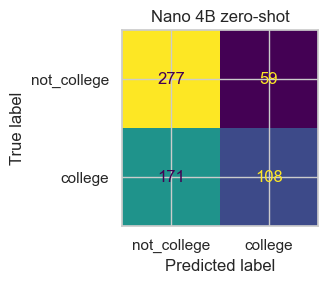

In [12]:
zs_metrics = evaluate_llm_results(zs_df, "Nano 4B zero-shot")
all_results.append(zs_metrics)

## 11. Experiment B: Few-shot

> Expected time: shown in timing estimate above.

In [13]:
print(f"Starting few-shot on {len(df_test)} test rows...")
print(f"Estimated time: ~{len(df_test) * 6 / 60:.0f} minutes\n")

fs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_few_shot_prompt(row.to_dict(), few_shot_examples)
    result   = classify_row(messages)
    fs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row["audit_verdict"],
        "verdict_num":   row["verdict_num"],
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(fs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(f"{RESULTS_DIR}/week3_fewshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week3_fewshot_raw.csv")

Starting few-shot on 615 test rows...
Estimated time: ~62 minutes

  Row  100/615 | Elapsed: 7.6min | Remaining: ~39.1min
  Row  200/615 | Elapsed: 15.6min | Remaining: ~32.4min
  Row  300/615 | Elapsed: 22.9min | Remaining: ~24.0min
  Row  400/615 | Elapsed: 30.4min | Remaining: ~16.4min
  Row  500/615 | Elapsed: 38.0min | Remaining: ~8.7min
  Row  600/615 | Elapsed: 45.6min | Remaining: ~1.1min

Done! Total time: 46.7 minutes
Saved: results/week3_fewshot_raw.csv


## 12. Few-shot Results


  Nano 4B few-shot
  Rows evaluated: 615 / 615
  Unknown:        0
  Accuracy:       0.6846
  Macro F1:       0.6845
  AUC-ROC:        0.6894
  Avg time/row:   4553ms

              precision    recall  f1-score   support

 not_college       0.75      0.64      0.69       336
     college       0.63      0.74      0.68       279

    accuracy                           0.68       615
   macro avg       0.69      0.69      0.68       615
weighted avg       0.69      0.68      0.68       615



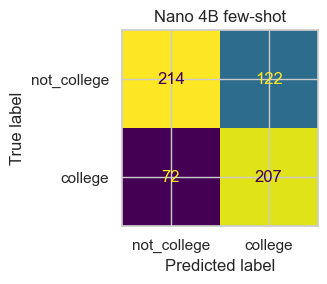

In [14]:
fs_metrics = evaluate_llm_results(fs_df, "Nano 4B few-shot")
all_results.append(fs_metrics)

## 13. Accuracy by Occupation Difficulty (Yes / No / Maybe)

=== ACCURACY BY OCCUPATION DIFFICULTY ===

YES (183 rows):
  Zero-shot: 62.8%
  Few-shot:  72.1%
  Top occs:  ['software developer', 'accountant or auditor', 'elementary or middle school teacher']

NO (320 rows):
  Zero-shot: 70.0%
  Few-shot:  70.9%
  Top occs:  ['customer service representative', 'driver sales worker or truck driver', 'cashier']

MAYBE (112 rows):
  Zero-shot: 41.1%
  Few-shot:  55.4%
  Top occs:  ['manager', 'sales representative wholesale or manufacturing', 'police officer']


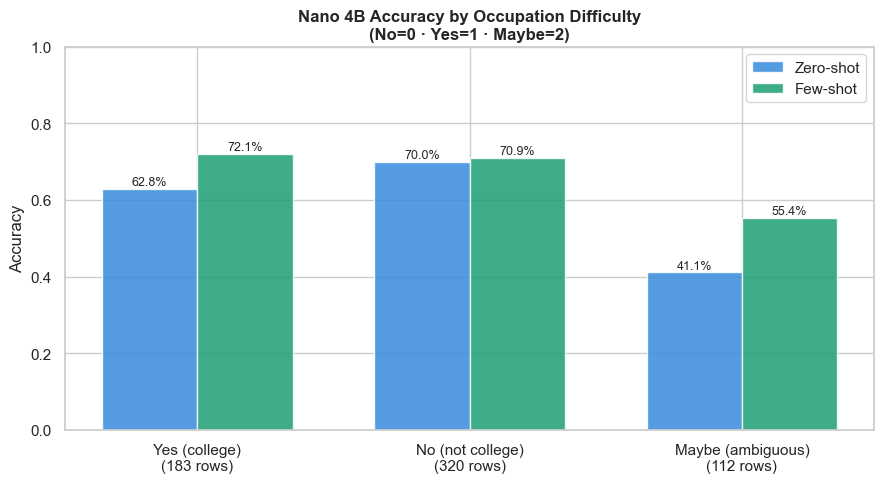

Saved: results/week3_accuracy_by_difficulty.png


In [15]:
verdict_labels = ["yes", "no", "maybe"]
verdict_names  = ["Yes (college)", "No (not college)", "Maybe (ambiguous)"]
zs_accs, fs_accs, sizes = [], [], []

print("=== ACCURACY BY OCCUPATION DIFFICULTY ===")
for verdict in verdict_labels:
    zs_sub   = zs_df[zs_df["audit_verdict"] == verdict]
    fs_sub   = fs_df[fs_df["audit_verdict"] == verdict]
    zs_valid = zs_sub[zs_sub["pred_label"].isin(["college", "not_college"])]
    fs_valid = fs_sub[fs_sub["pred_label"].isin(["college", "not_college"])]
    zs_acc   = (zs_valid["pred_label"] == zs_valid["true_label"]).mean() if len(zs_valid) > 0 else 0
    fs_acc   = (fs_valid["pred_label"] == fs_valid["true_label"]).mean() if len(fs_valid) > 0 else 0
    zs_accs.append(zs_acc)
    fs_accs.append(fs_acc)
    sizes.append(len(zs_sub))
    top_occs = zs_sub["occupation"].value_counts().head(3).index.tolist()
    print(f"\n{verdict.upper()} ({len(zs_sub)} rows):")
    print(f"  Zero-shot: {zs_acc:.1%}")
    print(f"  Few-shot:  {fs_acc:.1%}")
    print(f"  Top occs:  {top_occs}")

# Bar chart
x = range(3)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], zs_accs, width, label="Zero-shot", color="#378ADD", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], fs_accs, width, label="Few-shot",  color="#1D9E75", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{n}\n({s} rows)" for n, s in zip(verdict_names, sizes)])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Nano 4B Accuracy by Occupation Difficulty\n(No=0 · Yes=1 · Maybe=2)",
             fontsize=12, fontweight="bold")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_accuracy_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_accuracy_by_difficulty.png")

## 14. K-Means Cluster Analysis

In [16]:
cluster_features = ["age", "sex", "marital_status", "occupation", "state"]
X_cluster = df_test[cluster_features].copy()

le_dict = {}
for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    le_dict[col] = le

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

K  = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_arr = km.fit_predict(X_scaled)

zs_df["cluster"] = cluster_labels_arr
fs_df["cluster"] = cluster_labels_arr

cluster_stats = []
for c in range(K):
    zs_rows  = zs_df[zs_df["cluster"] == c]
    fs_rows  = fs_df[fs_df["cluster"] == c]
    zs_valid = zs_rows[zs_rows["pred_label"].isin(["college", "not_college"])]
    fs_valid = fs_rows[fs_rows["pred_label"].isin(["college", "not_college"])]
    zs_acc   = (zs_valid["pred_label"] == zs_valid["true_label"]).mean()
    fs_acc   = (fs_valid["pred_label"] == fs_valid["true_label"]).mean()
    size     = len(zs_rows)
    college_rate = (zs_rows["true_label"] == "college").mean()
    cluster_ids  = zs_rows["row_id"].values
    top_occ      = df_test.loc[df_test.index.isin(cluster_ids), "occupation"].value_counts().head(3).index.tolist()
    avg_age      = df_test.loc[df_test.index.isin(cluster_ids), "age"].mean()
    verdicts     = zs_rows["audit_verdict"].dropna()
    dominant     = verdicts.value_counts().idxmax() if len(verdicts) > 0 else "unaudited"
    top_occ_str  = ", ".join(top_occ)

    cluster_stats.append({
        "cluster":          c,
        "size":             size,
        "zs_accuracy":      round(zs_acc, 3),
        "fs_accuracy":      round(fs_acc, 3),
        "college_rate":     round(college_rate, 3),
        "avg_age":          round(avg_age, 1),
        "dominant_verdict": dominant,
        "top_occupations":  top_occ_str,
    })

    print(f"\n── Cluster {c} ─────────────────────────────────────────")
    print(f"  Size:               {size} rows")
    print(f"  Zero-shot accuracy: {zs_acc:.1%}")
    print(f"  Few-shot accuracy:  {fs_acc:.1%}")
    print(f"  College rate:       {college_rate:.1%}")
    print(f"  Avg age:            {avg_age:.1f}")
    print(f"  Dominant verdict:   {dominant}")
    print(f"  Top occupations:    {top_occ_str}")

cluster_df = pd.DataFrame(cluster_stats)
cluster_df.to_csv(f"{RESULTS_DIR}/week3_cluster_analysis.csv", index=False)
print("\nSaved: results/week3_cluster_analysis.csv")


── Cluster 0 ─────────────────────────────────────────
  Size:               170 rows
  Zero-shot accuracy: 64.1%
  Few-shot accuracy:  75.3%
  College rate:       47.1%
  Avg age:            52.5
  Dominant verdict:   no
  Top occupations:    software_developer, secretary_or_administrative_assistant, financial_manager

── Cluster 1 ─────────────────────────────────────────
  Size:               122 rows
  Zero-shot accuracy: 63.1%
  Few-shot accuracy:  61.5%
  College rate:       34.4%
  Avg age:            34.5
  Dominant verdict:   no
  Top occupations:    driver_sales_worker_or_truck_driver, customer_service_representative, first_line_supervisor_of_retail_sales_worker

── Cluster 2 ─────────────────────────────────────────
  Size:               156 rows
  Zero-shot accuracy: 62.2%
  Few-shot accuracy:  73.1%
  College rate:       48.1%
  Avg age:            33.6
  Dominant verdict:   no
  Top occupations:    cashier, elementary_or_middle_school_teacher, janitor_or_building_cleaner

## 15. Cluster Visualization

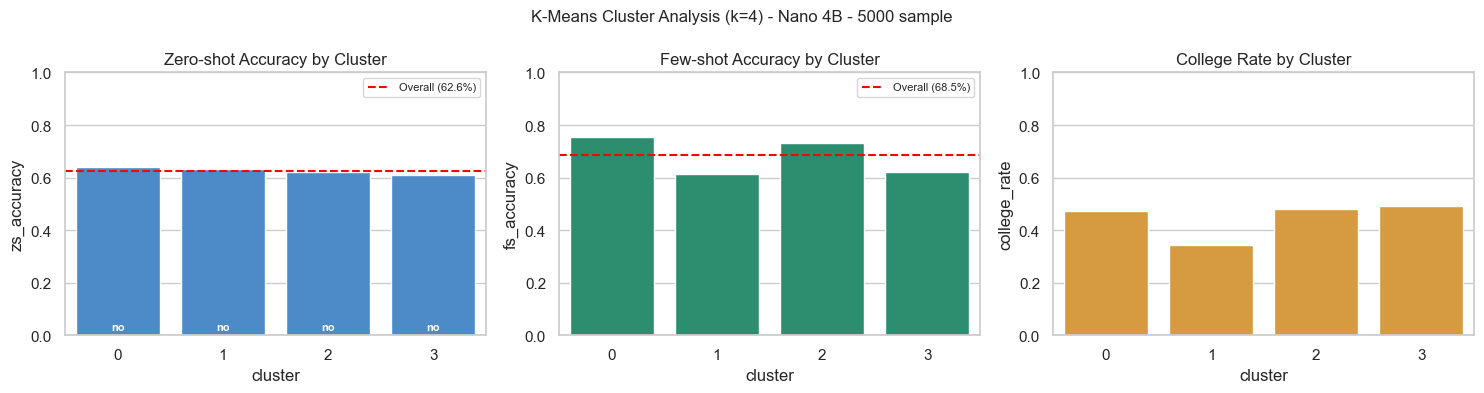

Saved: results/week3_cluster_accuracy.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=cluster_df, x="cluster", y="zs_accuracy", color="#378ADD", ax=axes[0])
axes[0].axhline(y=zs_df["correct"].mean(), color="red", linestyle="--",
                label=f'Overall ({zs_df["correct"].mean():.1%})')
axes[0].set_title("Zero-shot Accuracy by Cluster")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
for i, row in cluster_df.iterrows():
    axes[0].text(i, 0.02, row["dominant_verdict"], ha="center",
                 fontsize=8, color="white", fontweight="bold")

sns.barplot(data=cluster_df, x="cluster", y="fs_accuracy", color="#1D9E75", ax=axes[1])
axes[1].axhline(y=fs_df["correct"].mean(), color="red", linestyle="--",
                label=f'Overall ({fs_df["correct"].mean():.1%})')
axes[1].set_title("Few-shot Accuracy by Cluster")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

sns.barplot(data=cluster_df, x="cluster", y="college_rate", color="#EF9F27", ax=axes[2])
axes[2].set_title("College Rate by Cluster")
axes[2].set_ylim(0, 1)

plt.suptitle(f"K-Means Cluster Analysis (k={K}) - Nano 4B - 5000 sample", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_cluster_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_cluster_accuracy.png")

## 16. Save Results to metrics.csv

In [18]:
metrics_path = f"{RESULTS_DIR}/metrics.csv"
try:
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["week"] != 3]
    updated  = pd.concat([existing, pd.DataFrame(all_results)], ignore_index=True)
except FileNotFoundError:
    updated = pd.DataFrame(all_results)

updated.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(updated[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))

Saved: ../results/metrics.csv

                    model  accuracy  macro_f1  auc_roc  ms_per_row  week
Random Forest (100 trees)    0.6439    0.6400   0.6795       0.071     1
                  XGBoost    0.7089    0.7067   0.7447       0.006     1
        Nano 4B zero-shot    0.6260    0.5955   0.6058    3257.600     3
         Nano 4B few-shot    0.6846    0.6845   0.6894    4552.700     3


## 19. Week 3 Summary

